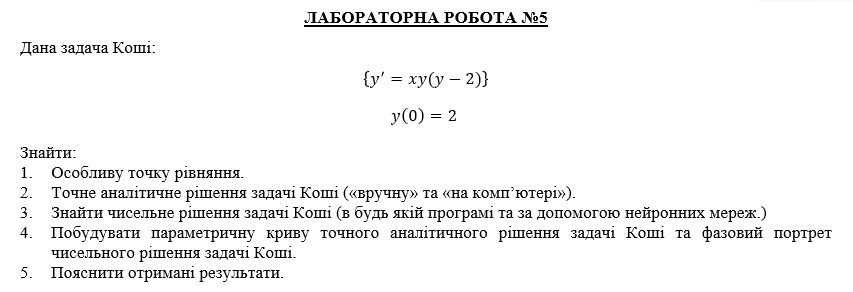

In [1]:
import sympy as sp

x = sp.symbols('x')
y = sp.Function('y')(x)

# Рівняння:y' = x*y*(y-2)
diff_eq = sp.Eq(y.diff(x), x * y * (y - 2))

# Початкові умови
ics = {y.subs(x, 0): 2}

# Розв'язання
sol = sp.dsolve(diff_eq, y, ics=ics)
print(f"Аналітичний розв'язок: y(x) = {sol.rhs}")


Аналітичний розв'язок: y(x) = 2


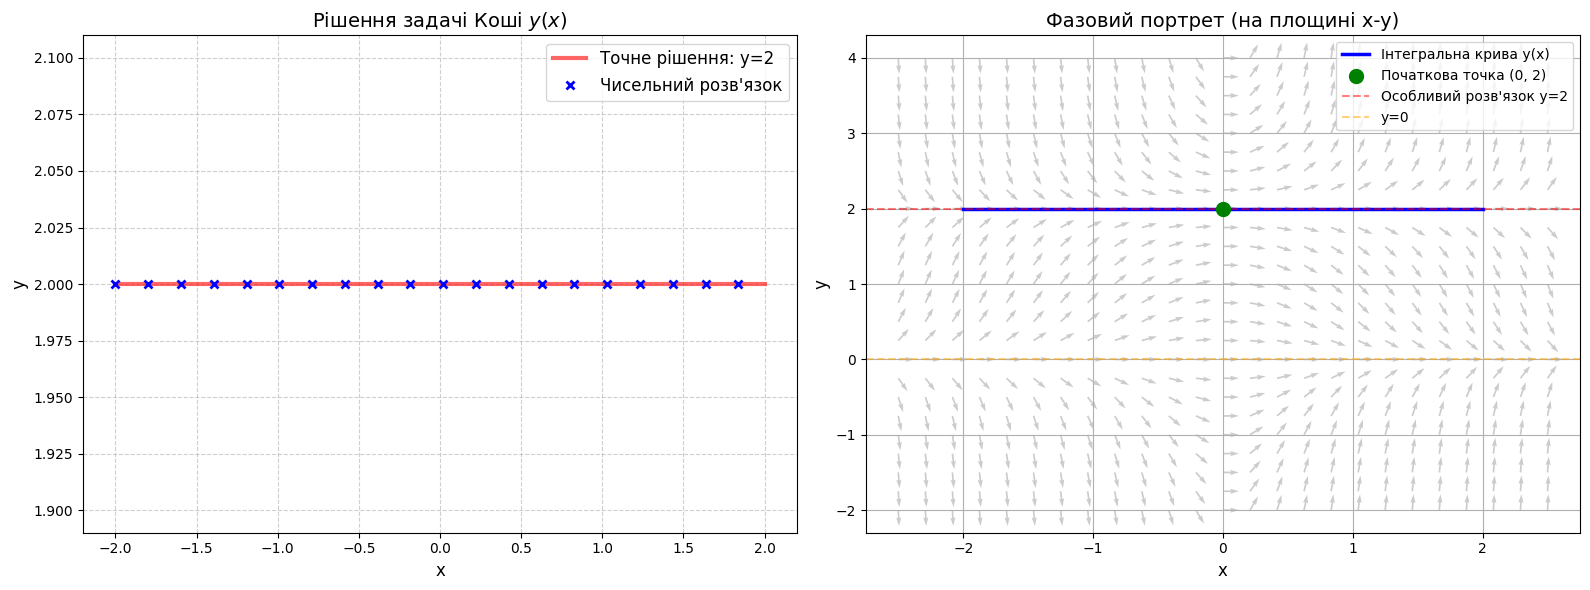

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# рівняння y' = x*y*(y-2)
def first_order_ode(y, x):
    dydx = x * y * (y - 2)
    return dydx

# Інтервал x
x = np.linspace(-2, 2, 100)

# Початкова умова
y0 = 2.0

# Точне аналітичне рішення y(x) = 2
y_exact = np.full_like(x, 2.0)

# Розв'язок
sol_numeric = odeint(first_order_ode, y0, x)
y_num = sol_numeric[:, 0]

# Побудова графіків
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Графік 1: Рішення y(x)
ax[0].plot(x, y_exact, 'r-', linewidth=3, label='Точне рішення: y=2', alpha=0.6)
ax[0].plot(x[::5], y_num[::5], 'bx', label='Чисельний розв\'язок', markeredgewidth=2)
ax[0].set_title("Рішення задачі Коші $y(x)$", fontsize=14)
ax[0].set_xlabel("x", fontsize=12)
ax[0].set_ylabel("y", fontsize=12)
ax[0].grid(True, linestyle='--', alpha=0.6)
ax[0].legend(fontsize=12)

# Графік 2: Фазовий портрет (Поле напрямків)
X_val = np.linspace(-2.5, 2.5, 25)
Y_val = np.linspace(-2, 4, 25)
X, Y = np.meshgrid(X_val, Y_val)

# Вектори напрямку: dx=1, dy = f(x,y)
U = 1
V = X * Y * (Y - 2)

# Нормалізація векторів
N = np.sqrt(U**2 + V**2)
U, V = U/N, V/N

ax[1].quiver(X, Y, U, V, color='gray', alpha=0.4)

# Траєкторія чисельного рішення
ax[1].plot(x, y_num, 'b-', linewidth=2.5, label='Інтегральна крива y(x)')
ax[1].scatter([0], [2], color='green', s=100, zorder=5, label='Початкова точка (0, 2)')

# Лінії рівноваги (особливі розв'язки)
ax[1].axhline(2, color='red', linestyle='--', alpha=0.5, label='Особливий розв\'язок y=2')
ax[1].axhline(0, color='orange', linestyle='--', alpha=0.5, label='y=0')

ax[1].set_title("Фазовий портрет (на площині x-y)", fontsize=14)
ax[1].set_xlabel("x", fontsize=12)
ax[1].set_ylabel("y", fontsize=12)
ax[1].grid(True)
ax[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

Починаємо навчання нейромережі для y' = xy(y-2)...
Epoch 0, Loss: 5.049759
Epoch 500, Loss: 0.001996
Epoch 1000, Loss: 0.000780
Epoch 1500, Loss: 0.000511
Epoch 2000, Loss: 0.000404
Epoch 2500, Loss: 0.000352
Навчання завершено.


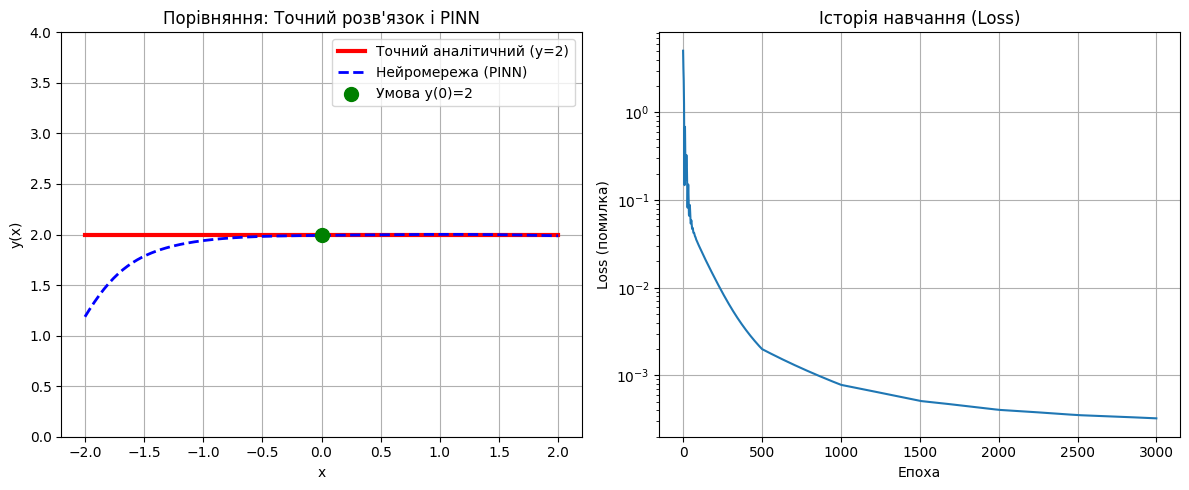

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# Створення Нейромережі
class PINN(nn.Module):
    def __init__(self):
        super(PINN, self).__init__()
        # Вхід (x) -> Приховані шари -> Вихід (y)
        self.net = nn.Sequential(
            nn.Linear(1, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
            nn.Tanh(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

#  Функція для обчислення похідних
def get_derivatives(model, x):
    """
    Обчислює y та y' (dy/dx)
    """
    x.requires_grad = True
    y = model(x)
    dy = torch.autograd.grad(y, x, torch.ones_like(y), create_graph=True)[0]
    return y, dy

# Фіксація random seed для відтворюваності результату
torch.manual_seed(42)
np.random.seed(42)

# Підготовка до навчання
model = PINN()
optimizer = optim.Adam(model.parameters(), lr=0.005)

# Планувальник (Scheduler)
# Кожні 1000 епох зменшує швидкість навчання в 2 рази (gamma=0.5)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=500, gamma=0.5)

# Точки тренування: інтервал [-2, 2]
x_train = torch.linspace(-2, 2, 100).view(-1, 1)

# Навчання нейромережі
epochs = 3000
loss_history = []

print("Починаємо навчання нейромережі для y' = xy(y-2)...")

for epoch in range(epochs):
    optimizer.zero_grad()

    # Обчислення значень
    y_pred, dy_pred = get_derivatives(model, x_train)

    # ЗМІНА 1: Рівняння (Physics Loss)
    # y' = xy(y-2)  =>  y' - xy(y-2) = 0
    ode_residual = dy_pred - x_train * y_pred * (y_pred - 2)
    loss_ode = torch.mean(ode_residual**2)

    # ЗМІНА 2: Початкові умови (Boundary Loss)
    # Умова: y(0) = 2
    x0 = torch.tensor([[0.0]], requires_grad=True)
    y0, _ = get_derivatives(model, x0)

    loss_ic = (y0 - 2)**2

    # Загальний Loss
    loss = loss_ode + loss_ic

    loss.backward()
    optimizer.step()
    scheduler.step()

    loss_history.append(loss.item())

    if epoch % 500 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.6f}")

print("Навчання завершено.")

# Візуалізація результатів

# Тестові дані для графіка
x_test = torch.linspace(-2, 2, 200).view(-1, 1)
with torch.no_grad():
    y_nn = model(x_test).numpy()

x_val = x_test.numpy()

# Точний розв'язок: y(x) = 2
y_exact = np.full_like(x_val, 2.0)

plt.figure(figsize=(12, 5))

# Графік 1: Порівняння розв'язків
plt.subplot(1, 2, 1)
plt.plot(x_val, y_exact, 'r-', linewidth=3, label='Точний аналітичний (y=2)')
plt.plot(x_val, y_nn, 'b--', linewidth=2, label='Нейромережа (PINN)')
# Додамо точку старту для наочності
plt.scatter([0], [2], color='green', s=100, zorder=5, label='Умова y(0)=2')

plt.title('Порівняння: Точний розв\'язок і PINN')
plt.xlabel('x')
plt.ylabel('y(x)')
plt.ylim(0, 4)
plt.legend()
plt.grid(True)

# Графік 2: Графік помилки навчання (Loss)
plt.subplot(1, 2, 2)
plt.plot(loss_history)
plt.yscale('log')
plt.title('Історія навчання (Loss)')
plt.xlabel('Епоха')
plt.ylabel('Loss (помилка)')
plt.grid(True)

plt.tight_layout()
plt.show()